<a href="https://colab.research.google.com/github/TBGhorbanpour/Social-Awareness/blob/main/Temporal_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/DBF0.8.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/ّPolitical_Filtered_lemma.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.shape

(75455, 17)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [ ]:
# Drop irrelevant columns if necessary
df_cleaned = df[['ID', 'Date', 'Likes', 'Retweet', 'Replies', 'lemmatized_tweet']]

In [ ]:
# Convert 'Date' to datetime type and set it as the index using .loc
df_cleaned.loc[:, 'Date'] = pd.to_datetime(df_cleaned['Date'])
df_cleaned.set_index('Date', inplace=True)

# Resample data to daily frequency
df_daily = df_cleaned.resample('D').count()

In [ ]:
print(df_cleaned.columns)


Index(['ID', 'Date', 'Likes', 'Retweet', 'Replies', 'lemmatized_tweet'], dtype='object')


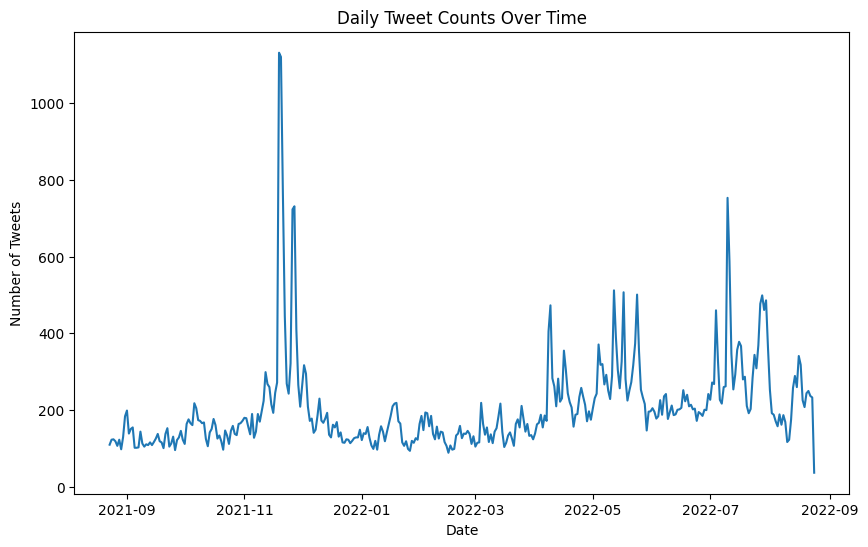

In [ ]:
########not mentioned
# Plot daily tweet counts
plt.figure(figsize=(10, 6))
sns.lineplot(x=df_daily.index, y='ID', data=df_daily)
plt.title('Daily Tweet Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.show()


<ipython-input-35-a273e59ed2f7>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Dominant_Topic'] = topic_probs.argmax(axis=1)
<ipython-input-35-a273e59ed2f7>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])


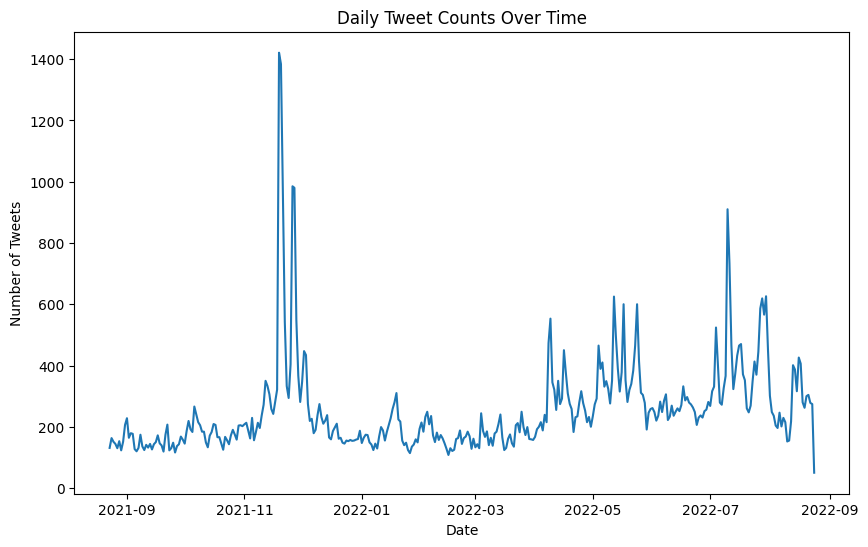

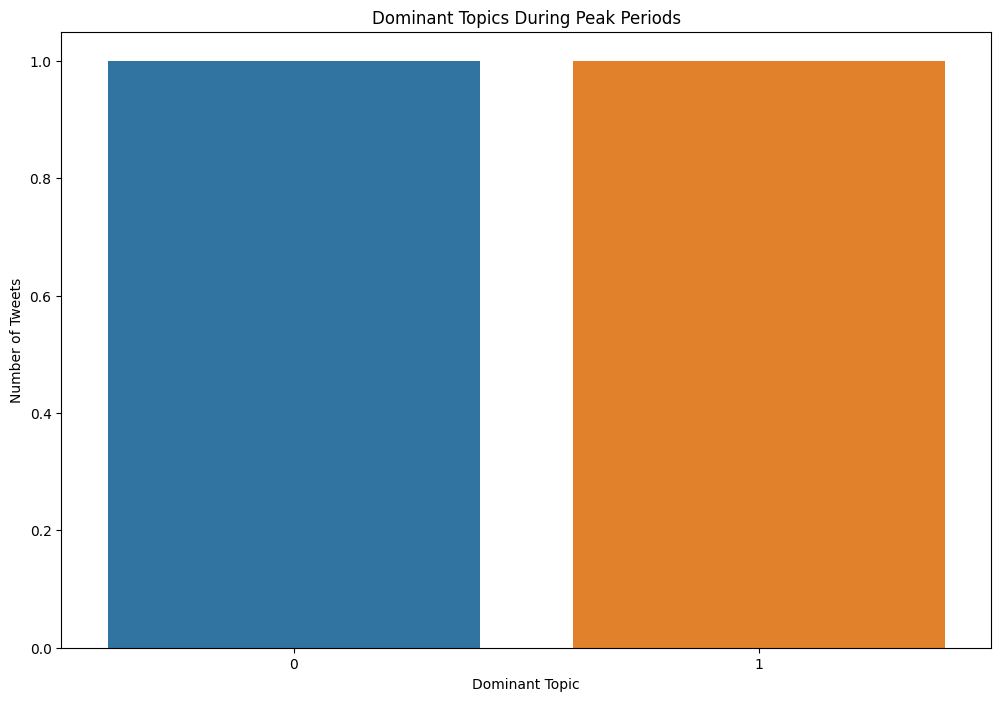

In [ ]:
########not mentioned
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_cleaned is already defined and contains the necessary columns

# Step 1: Train LDA model
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
lemmatized_tweets = df_cleaned['lemmatized_tweet'].values.astype('U')
X = vectorizer.fit_transform(lemmatized_tweets)

num_topics = 5  # Adjust the number of topics as needed
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(X)

# Step 2: Transform the data to get topic probabilities for each tweet
topic_probs = lda.transform(X)

# Step 3: Add a new column to df_cleaned with the dominant topic for each tweet
df_cleaned['Dominant_Topic'] = topic_probs.argmax(axis=1)

# Set 'Date' as the index
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])
df_cleaned.set_index('Date', inplace=True)

# Step 4: Resample data to daily frequency
df_daily = df_cleaned.resample('D').count()

# Plot daily tweet counts
plt.figure(figsize=(10, 6))
sns.lineplot(x=df_daily.index, y='lemmatized_tweet', data=df_daily)
plt.title('Daily Tweet Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.show()

# Identify peaks in the daily tweet counts
peak_threshold = 800  # Adjust the threshold based on your observation
peaks = df_daily[df_daily['lemmatized_tweet'] > peak_threshold]  # Change 'ID' to 'lemmatized_tweet'

# Extract tweets falling within the peak periods
tweets_within_peaks = df_cleaned.loc[df_cleaned.index.isin(peaks.index)]

# Plot the distribution of dominant topics during peak periods
plt.figure(figsize=(12, 8))
sns.countplot(x='Dominant_Topic', data=tweets_within_peaks)
plt.title('Dominant Topics During Peak Periods')
plt.xlabel('Dominant Topic')
plt.ylabel('Number of Tweets')
plt.show()


<ipython-input-20-00ef19007d85>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Dominant_Topic'] = topic_probs.argmax(axis=1)
<ipython-input-20-00ef19007d85>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])


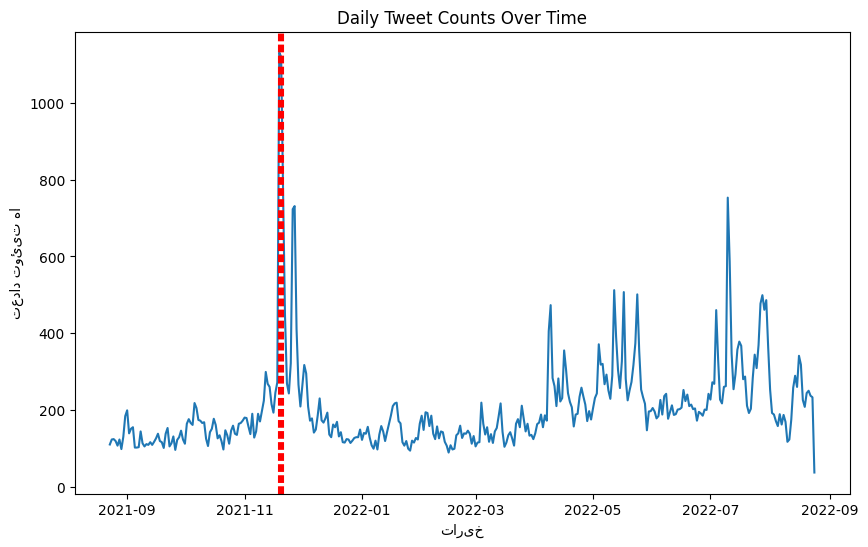

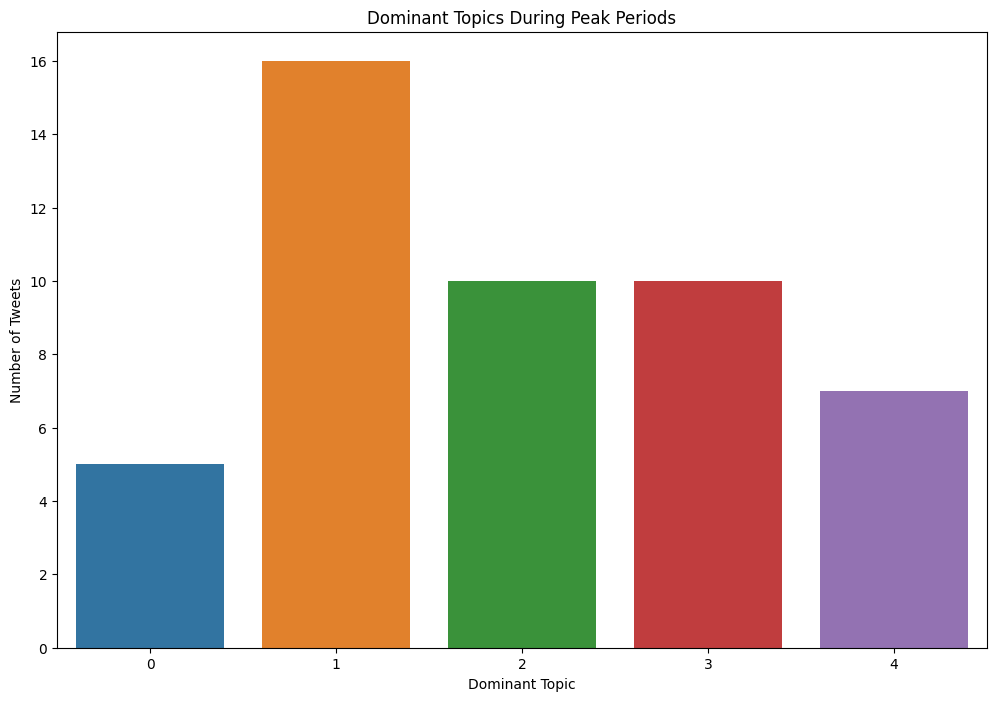

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_cleaned is already defined and contains the necessary columns

# Step 1: Train LDA model
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
lemmatized_tweets = df_cleaned['lemmatized_tweet'].values.astype('U')
X = vectorizer.fit_transform(lemmatized_tweets)

num_topics = 5  # Adjust the number of topics as needed
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(X)

# Step 2: Transform the data to get topic probabilities for each tweet
topic_probs = lda.transform(X)

# Step 3: Add a new column to df_cleaned with the dominant topic for each tweet
df_cleaned['Dominant_Topic'] = topic_probs.argmax(axis=1)

# Set 'Date' as the index
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])
df_cleaned.set_index('Date', inplace=True)

# Step 4: Resample data to daily frequency
df_daily = df_cleaned.resample('D').count()

# Plot daily tweet counts
plt.figure(figsize=(10, 6))
sns.lineplot(x=df_daily.index, y='lemmatized_tweet', data=df_daily)
plt.title('Daily Tweet Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')

# Identify peaks in the daily tweet counts
peak_threshold = 100  # Adjust the threshold based on your observation
peaks = df_daily[df_daily['lemmatized_tweet'] > peak_threshold]  # Change 'ID' to 'lemmatized_tweet'

# Find the first three peak dates
first_three_peaks = peaks.nlargest(3, 'lemmatized_tweet').index

# Highlight the first three peaks on the plot
for peak_date in first_three_peaks:
    plt.axvline(x=peak_date, color='r', linestyle='--', label=f'Peak ({peak_date.strftime("%Y-%m-%d")})')

# Extract tweets falling within the peak periods
tweets_within_peaks = df_cleaned.loc[df_cleaned.index.isin(peaks.index)]

# Plot the distribution of dominant topics during peak periods
plt.figure(figsize=(12, 8))
sns.countplot(x='Dominant_Topic', data=tweets_within_peaks)
plt.title('Dominant Topics During Peak Periods')
plt.xlabel('Dominant Topic')
plt.ylabel('Number of Tweets')
plt.show()


<ipython-input-54-e1760d0a406e>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Dominant_Topic'] = topic_probs.argmax(axis=1)
<ipython-input-54-e1760d0a406e>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])
<ipython-input-54-e1760d0a406e>:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

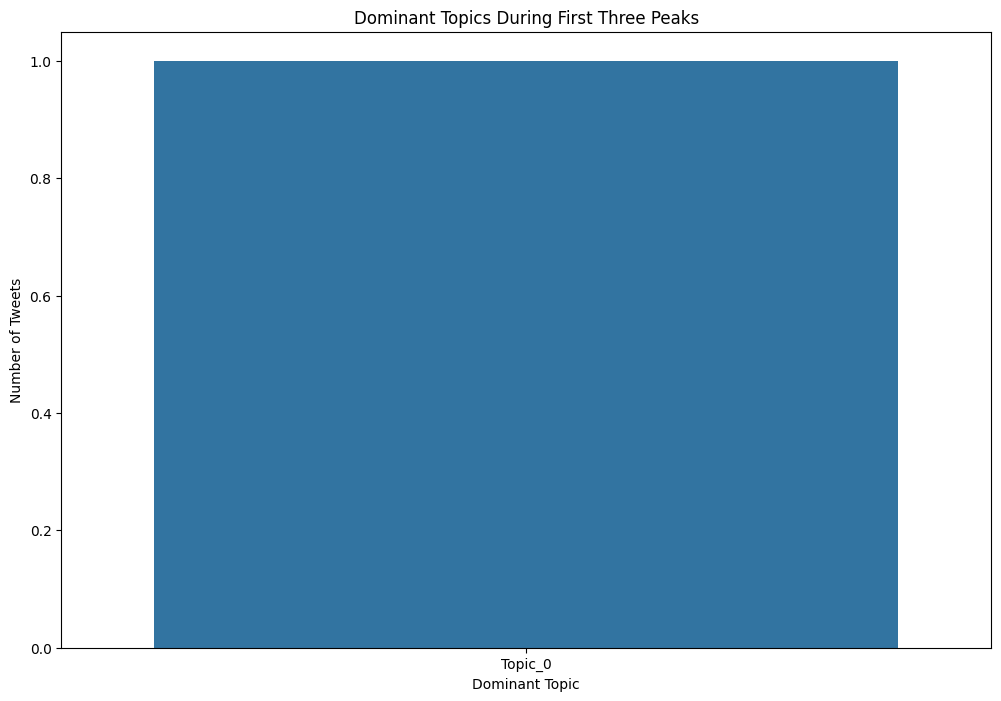

In [ ]:

########not mentioned
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_cleaned is already defined and contains the necessary columns

# Step 1: Train LDA model
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
lemmatized_tweets = df_cleaned['lemmatized_tweet'].values.astype('U')
X = vectorizer.fit_transform(lemmatized_tweets)

num_topics = 5  # Adjust the number of topics as needed
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(X)

# Step 2: Transform the data to get topic probabilities for each tweet
topic_probs = lda.transform(X)

# Step 3: Add a new column to df_cleaned with the dominant topic for each tweet
df_cleaned['Dominant_Topic'] = topic_probs.argmax(axis=1)

# Set 'Date' as the index
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])
df_cleaned.set_index('Date', inplace=True)

# Step 4: Resample data to daily frequency
df_daily = df_cleaned.resample('D').count()

# Identify peaks in the daily tweet counts
peak_threshold = 100  # Adjust the threshold based on your observation
peaks = df_daily[df_daily['lemmatized_tweet'] > peak_threshold]  # Change 'ID' to 'lemmatized_tweet'

# Find the first three peak dates
first_three_peaks = peaks.nlargest(3, 'lemmatized_tweet').index

# Extract tweets falling within the first three peaks
tweets_within_first_three_peaks = df_cleaned.loc[df_cleaned.index.isin(first_three_peaks)]

# Get the topic names from the LDA model
topic_names = [f'Topic_{i}' for i in range(num_topics)]

# Map numeric indices to dynamically retrieved topic names
tweets_within_first_three_peaks['Dominant_Topic'] = tweets_within_first_three_peaks['Dominant_Topic'].map({i: name for i, name in enumerate(topic_names)})

# Plot the distribution of dominant topics during the first three peaks
plt.figure(figsize=(12, 8))
sns.countplot(x='Dominant_Topic', data=tweets_within_first_three_peaks)
plt.title('Dominant Topics During First Three Peaks')
plt.xlabel('Dominant Topic')
plt.ylabel('Number of Tweets')
plt.show()


In [ ]:
# Drop irrelevant columns if necessary
df_cleaned = df[['ID', 'Date', 'Likes', 'Retweet', 'Replies', 'lemmatized_tweet','Keyword']]

<ipython-input-71-a50b8ff2ccfe>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])
<ipython-input-71-a50b8ff2ccfe>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Dominant_Topic'] = lda.transform(X).argmax(axis=1)
<ipython-input-71-a50b8ff2ccfe>:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

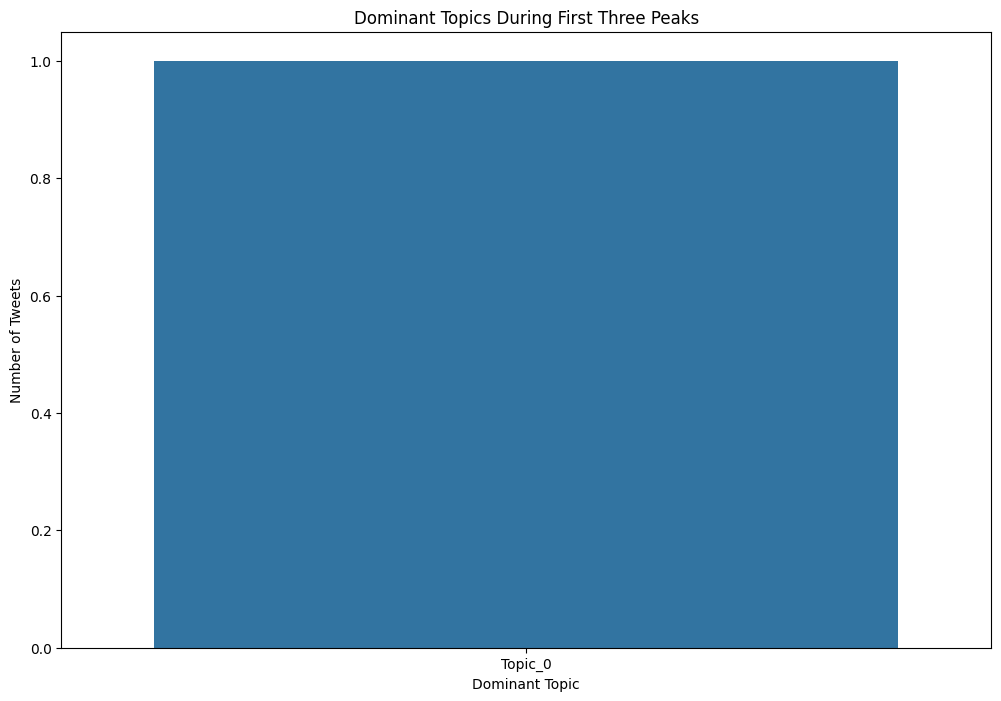

                      ID  Likes  Retweet  Replies  \
Date                                                
2021-11-20  1.460000e+18    3.0      0.0      1.0   

                                             lemmatized_tweet   Keyword  \
Date                                                                      
2021-11-20  ﮐﻠﯿﭗ ﻣﻨﻮﺕ ﻭﯾﺪﺋﻮ ﺗﻮﺋﯿﺖ ﺟﻤﻌﯿﺖ ﺍﺻﻔﻬﺎﻥ ﺍ ﺩﻭﺭﻩ ﺧﺸﮑﺴ...  خشک سالی   

            Dominant_Topic   Keyword  
Date                                  
2021-11-20               0  خشک سالی  


In [ ]:
########not mentioned
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_cleaned is already defined and contains the necessary columns

# Step 1: Train LDA model
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
lemmatized_tweets = df_cleaned['lemmatized_tweet'].values.astype('U')
X = vectorizer.fit_transform(lemmatized_tweets)

num_topics = 5  # Adjust the number of topics as needed
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(X)

# Get feature names (words) from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Map numeric indices to dynamically retrieved topic names
topic_names = [f'Topic_{i}' for i in range(num_topics)]

# Set 'Date' as the index
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])
df_cleaned.set_index('Date', inplace=True)

# Add a new column to df_cleaned with the dominant topic for each tweet
df_cleaned['Dominant_Topic'] = lda.transform(X).argmax(axis=1)

# Resample data to daily frequency
df_daily = df_cleaned.resample('D').count()

# Identify peaks in the daily tweet counts
peak_threshold = 100  # Adjust the threshold based on your observation
peaks = df_daily[df_daily['lemmatized_tweet'] > peak_threshold]  # Change 'ID' to 'lemmatized_tweet'

# Find the first three peak dates
first_three_peaks = peaks.nlargest(3, 'lemmatized_tweet').index

# Extract tweets falling within the first three peaks
tweets_within_first_three_peaks = df_cleaned.loc[df_cleaned.index.isin(first_three_peaks)]

# Map numeric indices to dynamically retrieved topic names
tweets_within_first_three_peaks['Dominant_Topic'] = tweets_within_first_three_peaks['Dominant_Topic'].map({i: topic_names[i] for i in range(num_topics)})

# Plot the distribution of dominant topics during the first three peaks
plt.figure(figsize=(12, 8))
sns.countplot(x='Dominant_Topic', data=tweets_within_first_three_peaks)
plt.title('Dominant Topics During First Three Peaks')
plt.xlabel('Dominant Topic')
plt.ylabel('Number of Tweets')
plt.show()

# Create a new DataFrame to store tweets and keywords of each peak
df_peaks_tweets_keywords = pd.DataFrame()

# Iterate over each peak and store tweets and keywords in the new DataFrame
for peak_date in first_three_peaks:
    peak_tweets = df_cleaned.loc[df_cleaned.index == peak_date]
    peak_keywords = df_cleaned.loc[df_cleaned.index == peak_date, 'Keyword']

    # Combine tweets and keywords into a single DataFrame
    peak_data = pd.concat([peak_tweets, peak_keywords], axis=1)
    df_peaks_tweets_keywords = pd.concat([df_peaks_tweets_keywords, peak_data])

# Display the new DataFrame with tweets and keywords of each peak
print(df_peaks_tweets_keywords)


In [ ]:
# Display the new DataFrame with tweets of each peak
df_peaks_tweets_keywords.head(10)

,ID,Likes,Retweet,Replies,lemmatized_tweet,Keyword,Dominant_Topic,Keyword
Date,,,,,,,,
2021-11-20,1.460000e+18,3.0,0.0,1.0,ﮐﻠﯿﭗ ﻣﻨﻮﺕ ﻭﯾﺪﺋﻮ ﺗﻮﺋﯿﺖ ﺟﻤﻌﯿﺖ ﺍﺻﻔﻬﺎﻥ ﺍ ﺩﻭﺭﻩ ﺧﺸﮑﺴ...,خشک سالی,0,خشک سالی


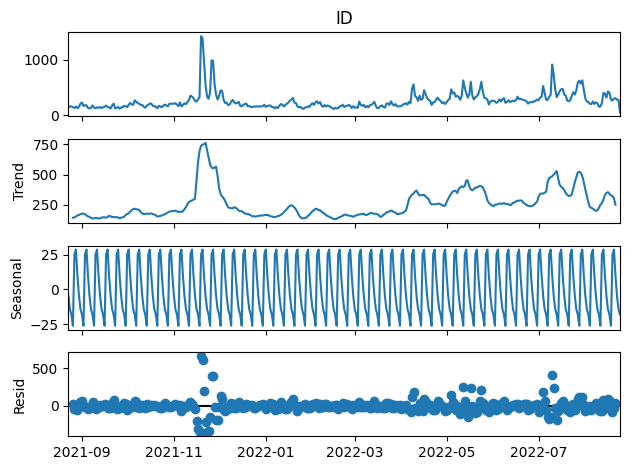

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series
result = seasonal_decompose(df_daily['ID'], model='additive', period=7)  # Set period based on observed patterns
# period= 7  یعنی بازه یک هفتگی و 7 روزه
#  model='additive' میتوان بصورت multiplicative هم بسته به نوع داده باشد

# Plot the decomposed components
result.plot()
plt.show()


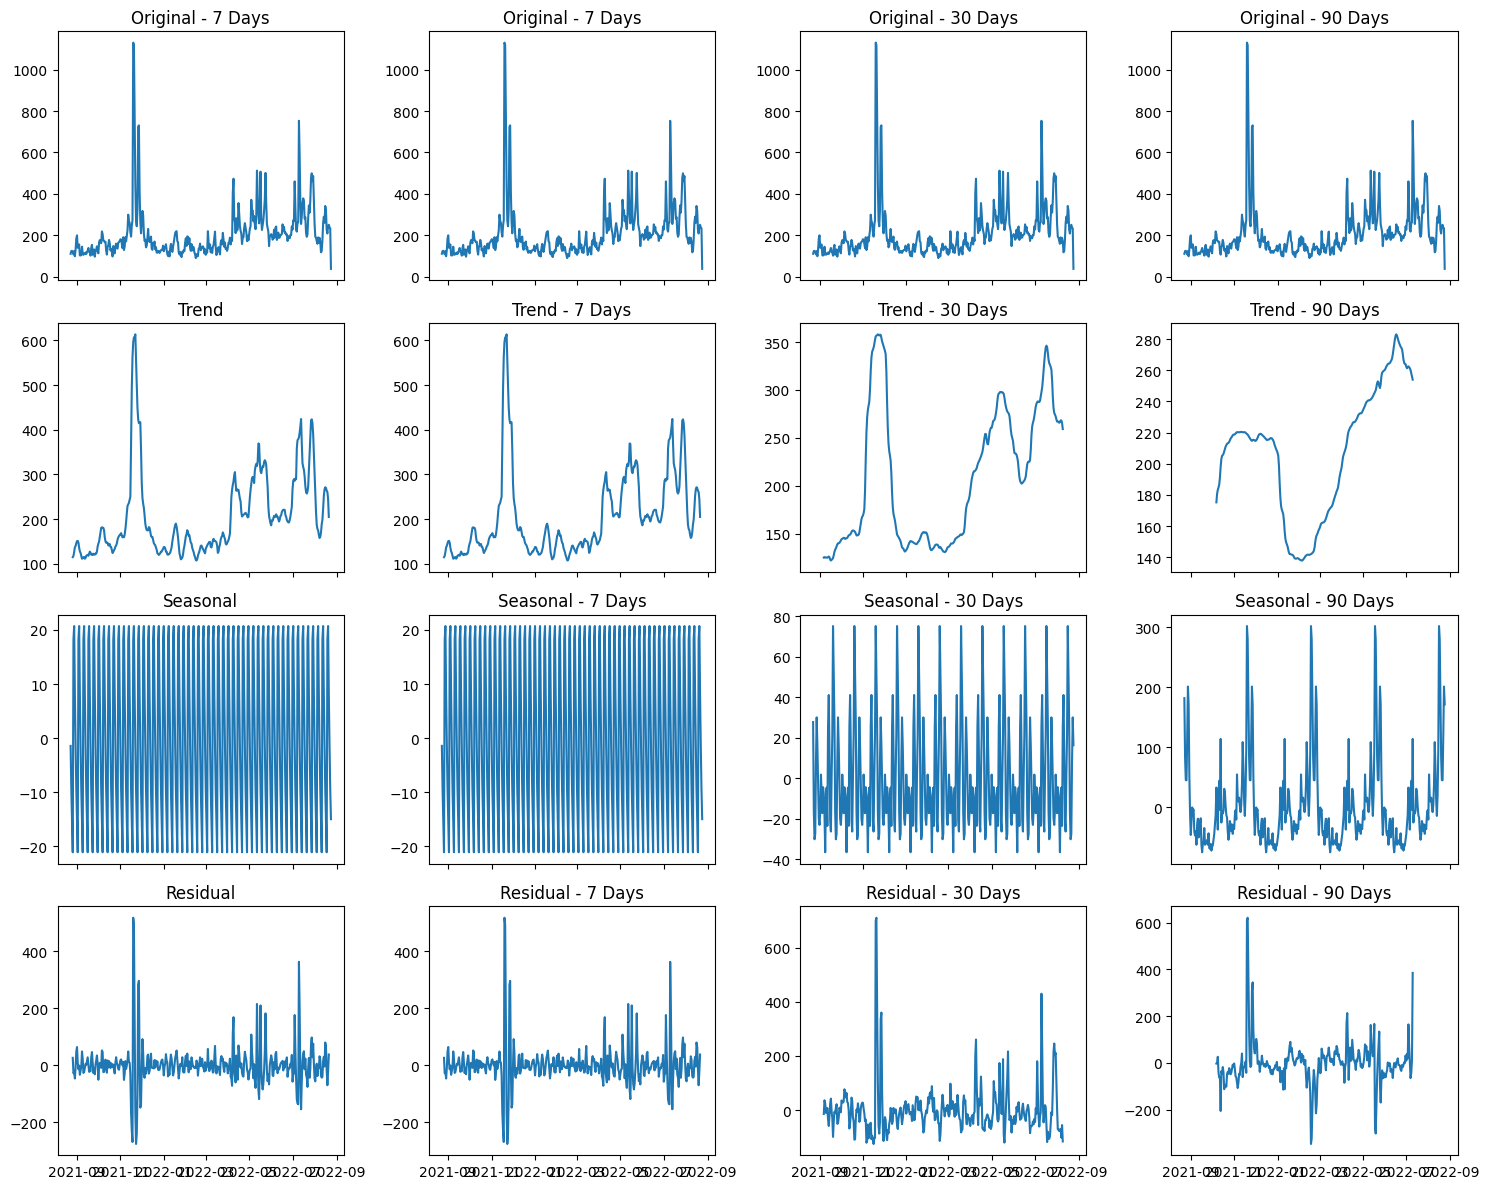

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Sample data (replace this with your actual data)
# df_daily = ...

# Function to plot the decomposed components for different periods
def plot_seasonal_decomposition(data, period):
    result = seasonal_decompose(data, model='additive', period=period)

    # Create subplots
    fig, axes = plt.subplots(4, 4, figsize=(15, 12), sharex=True)

    # Plot original time series
    axes[0, 0].set_title(f'Original - {period} Days')
    axes[0, 0].plot(data)

    # Plot trend component
    axes[1, 0].set_title('Trend')
    axes[1, 0].plot(result.trend)

    # Plot seasonal component
    axes[2, 0].set_title('Seasonal')
    axes[2, 0].plot(result.seasonal)

    # Plot residual component
    axes[3, 0].set_title('Residual')
    axes[3, 0].plot(result.resid)

    # Plot original time series for different days
    for i, day in enumerate([7, 30, 90]):
        result = seasonal_decompose(data, model='additive', period=day)

        axes[0, i+1].set_title(f'Original - {day} Days')
        axes[0, i+1].plot(data)

        axes[1, i+1].set_title(f'Trend - {day} Days')
        axes[1, i+1].plot(result.trend)

        axes[2, i+1].set_title(f'Seasonal - {day} Days')
        axes[2, i+1].plot(result.seasonal)

        axes[3, i+1].set_title(f'Residual - {day} Days')
        axes[3, i+1].plot(result.resid)

    plt.tight_layout()
    plt.show()

# Replace 'ID' with your actual column name
plot_seasonal_decomposition(df_daily['ID'], period=7)


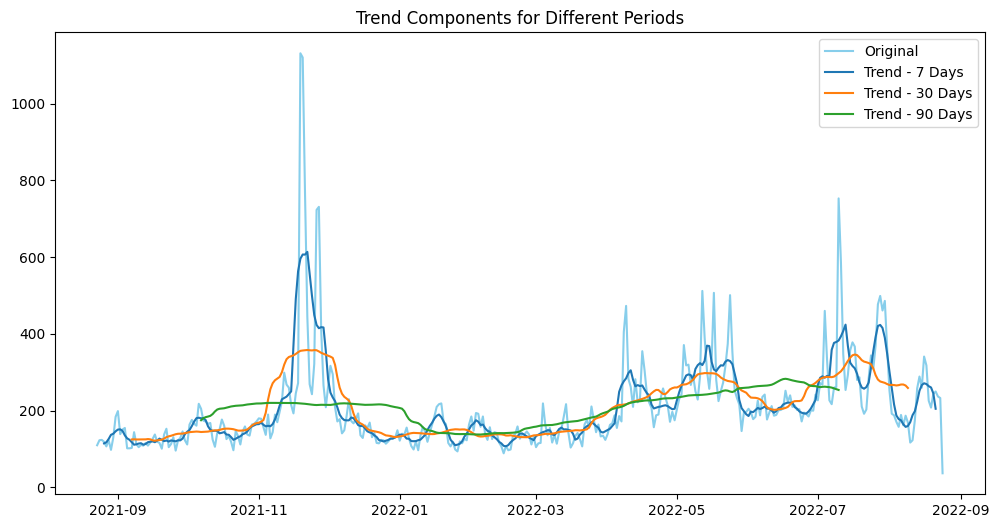

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Sample data (replace this with your actual data)
# df_daily = ...

# Function to plot trend components for different periods
def plot_trend_components(data, periods):
    # Create subplots
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot original time series
    ax.set_title('Trend Components for Different Periods')
    ax.plot(data, label='Original', color='skyblue')

    # Plot trend components for different periods
    for period in periods:
        result = seasonal_decompose(data, model='additive', period=period)
        ax.plot(result.trend, label=f'Trend - {period} Days')

    ax.legend()
    plt.show()

# Replace 'ID' with your actual column name
plot_trend_components(df_daily['ID'], periods=[7, 30, 90])


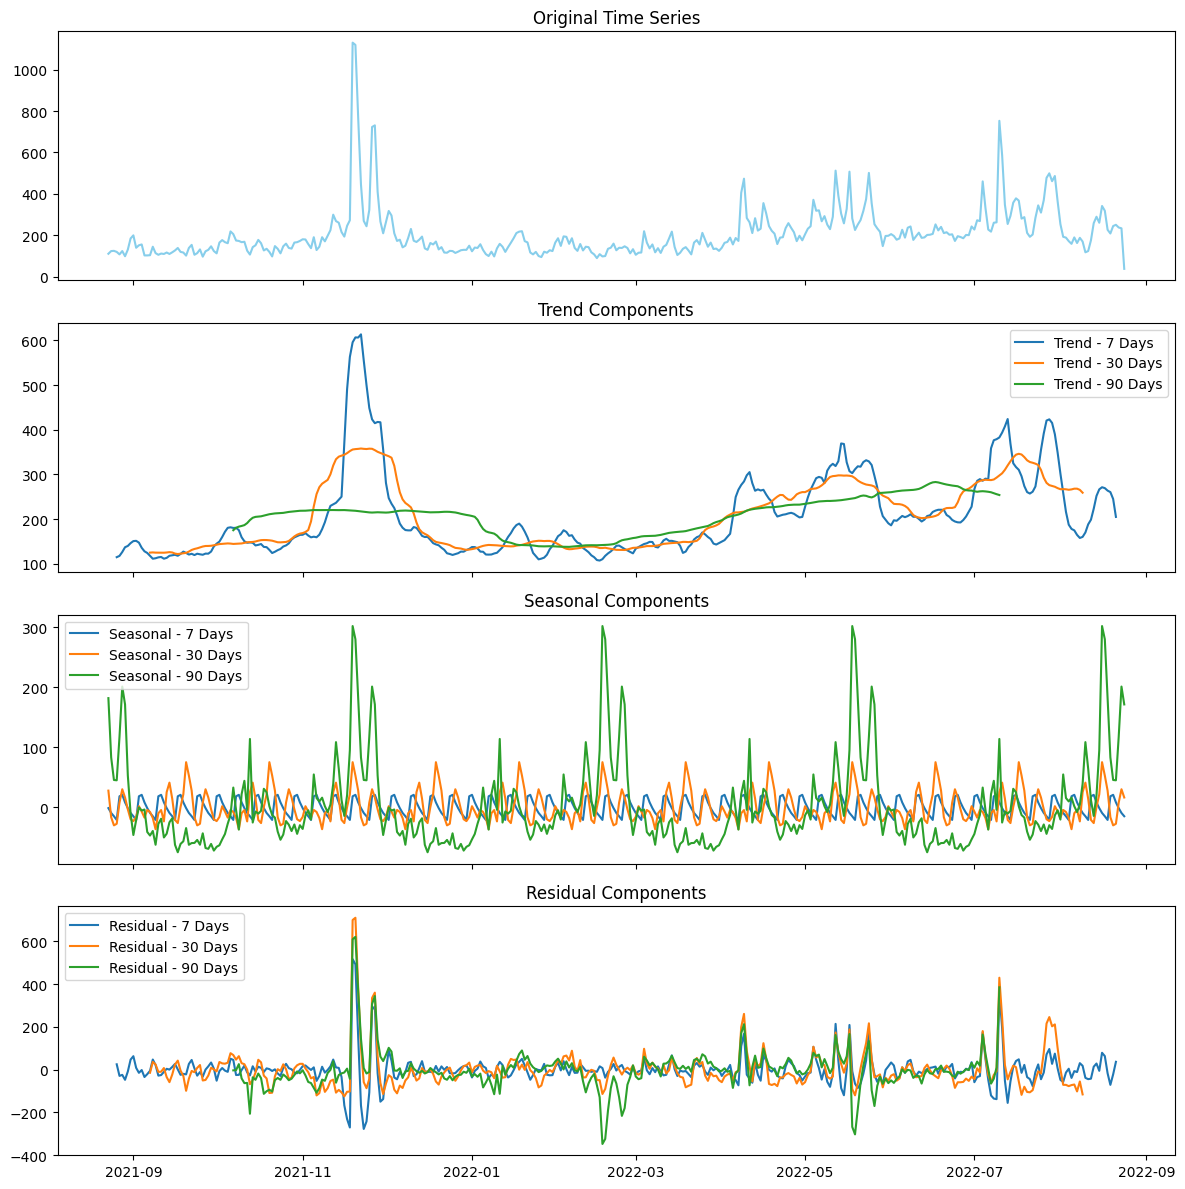

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Function to plot components for different periods
def plot_components(data, periods):
    # Create subplots
    fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

    # Plot original time series
    axes[0].set_title('Original Time Series')
    axes[0].plot(data, label='Original', color='black')

    # Plot components for different periods
    for period in periods:
        result = seasonal_decompose(data, model='additive', period=period)

        # Plot trend component
        axes[1].plot(result.trend, label=f'Trend - {period} Days')

        # Plot seasonal component
        axes[2].plot(result.seasonal, label=f'Seasonal - {period} Days')

        # Plot residual component
        axes[3].plot(result.resid, label=f'Residual - {period} Days')

    axes[1].set_title('Trend Components')
    axes[1].legend()

    axes[2].set_title('Seasonal Components')
    axes[2].legend()

    axes[3].set_title('Residual Components')
    axes[3].legend()

    plt.tight_layout()
    plt.show()

# Replace 'ID' with your actual column name
plot_components(df_daily['ID'], periods=[7, 30, 90])


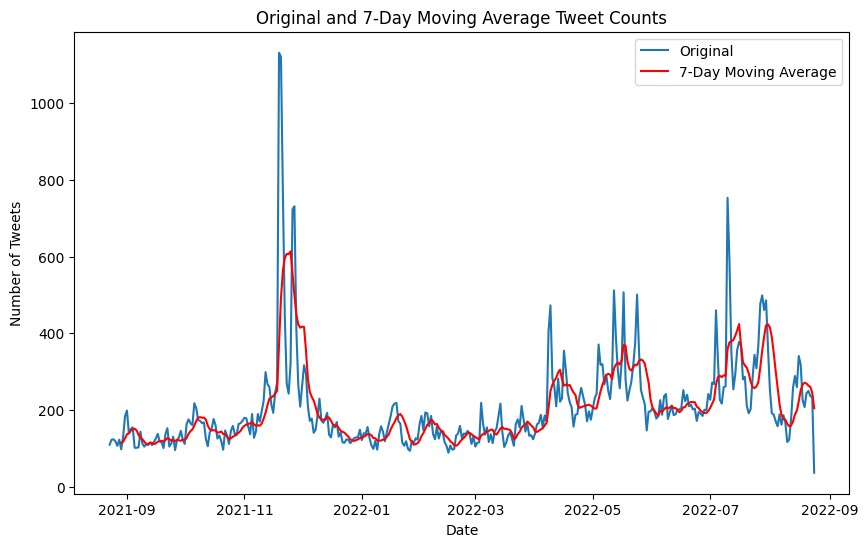

In [ ]:
# Calculate the weekly moving average
df_daily['ID_MA7'] = df_daily['ID'].rolling(window=7).mean()

# Plot the original and moving average time series
plt.figure(figsize=(10, 6))
plt.plot(df_daily.index, df_daily['ID'], label='Original')
plt.plot(df_daily.index, df_daily['ID_MA7'], label='7-Day Moving Average', color='red')
plt.title('Original and 7-Day Moving Average Tweet Counts')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.legend()
plt.show()


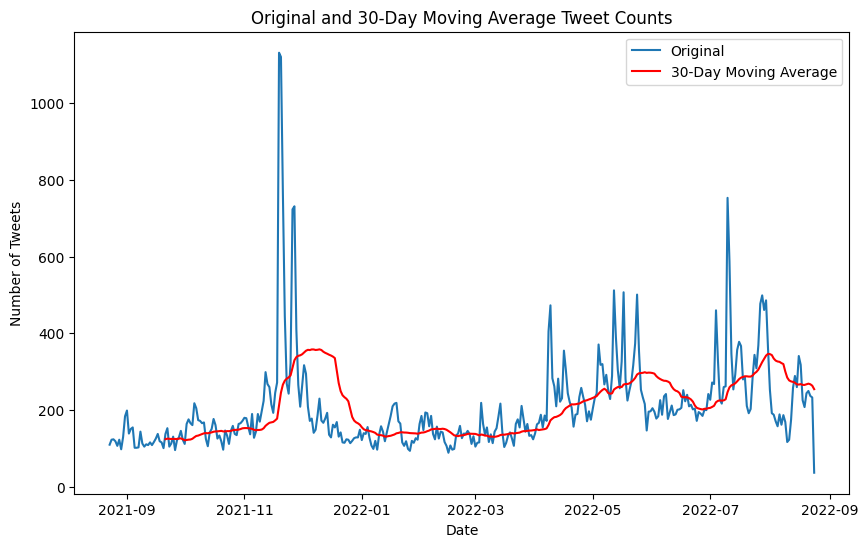

In [ ]:
# Calculate the 7-day moving average
df_daily['ID_MA7'] = df_daily['ID'].rolling(window=30).mean()

# Plot the original and moving average time series
plt.figure(figsize=(10, 6))
plt.plot(df_daily.index, df_daily['ID'], label='Original')
plt.plot(df_daily.index, df_daily['ID_MA7'], label='30-Day Moving Average', color='red')
plt.title('Original and 30-Day Moving Average Tweet Counts')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.legend()
plt.show()


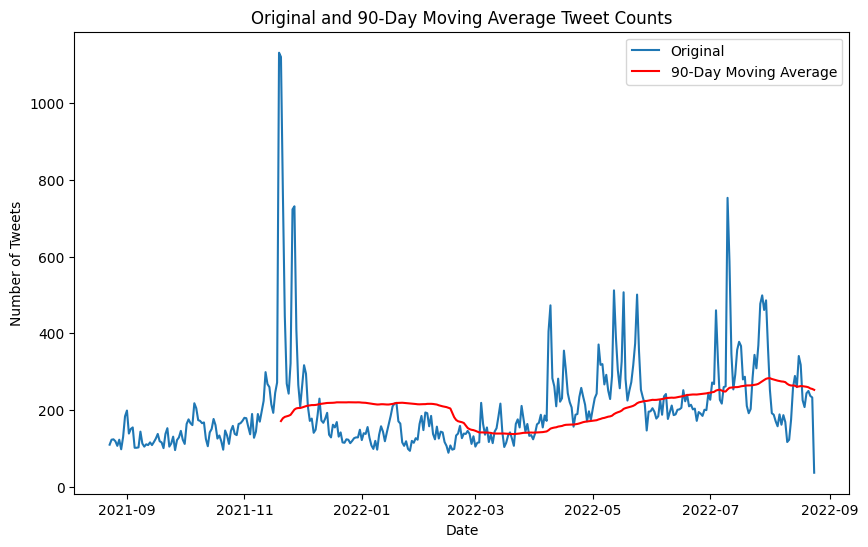

In [ ]:
# Calculate the 7-day moving average
df_daily['ID_MA7'] = df_daily['ID'].rolling(window=90).mean()

# Plot the original and moving average time series
plt.figure(figsize=(10, 6))
plt.plot(df_daily.index, df_daily['ID'], label='Original')
plt.plot(df_daily.index, df_daily['ID_MA7'], label='90-Day Moving Average', color='red')
plt.title('Original and 90-Day Moving Average Tweet Counts')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.legend()
plt.show()


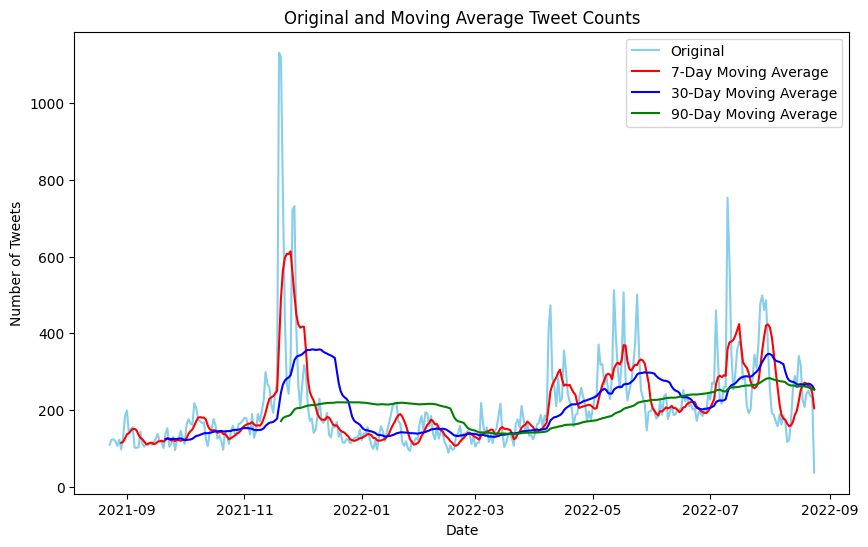

In [ ]:
import matplotlib.pyplot as plt

# Calculate the moving averages
df_daily['ID_MA7_7'] = df_daily['ID'].rolling(window=7).mean()
df_daily['ID_MA7_30'] = df_daily['ID'].rolling(window=30).mean()
df_daily['ID_MA7_90'] = df_daily['ID'].rolling(window=90).mean()

# Plot all three on the same chart
plt.figure(figsize=(10, 6))

# Plot the original time series
plt.plot(df_daily.index, df_daily['ID'], label='Original',color='skyblue')

# Plot the 7-Day Moving Average
plt.plot(df_daily.index, df_daily['ID_MA7_7'], label='7-Day Moving Average', color='red')

# Plot the 30-Day Moving Average
plt.plot(df_daily.index, df_daily['ID_MA7_30'], label='30-Day Moving Average', color='blue')

# Plot the 90-Day Moving Average
plt.plot(df_daily.index, df_daily['ID_MA7_90'], label='90-Day Moving Average', color='green')

# Customize the chart
plt.title('Original and Moving Average Tweet Counts')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.legend()
plt.show()


In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/ّPolitical_Filtered_lemma.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Drop irrelevant columns if necessary
df_cleaned = df[['ID', 'Date', 'Likes', 'Retweet', 'Replies', 'lemmatized_tweet']]

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Train LDA model
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
lemmatized_tweets = df_cleaned['lemmatized_tweet'].values.astype('U')
X = vectorizer.fit_transform(lemmatized_tweets)

num_topics = 5
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(X)

#Transform the data to get topic probabilities for each tweet
topic_probs = lda.transform(X)

#Add a new column to df_cleaned with the dominant topic for each tweet
df_cleaned['Dominant_Topic'] = topic_probs.argmax(axis=1)

# Plot daily tweet counts
plt.figure(figsize=(30, 15))
sns.lineplot(x=df_daily.index, y='lemmatized_tweet', data=df_daily)
plt.title('Daily Tweet Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')

# Identify peaks in the daily tweet counts
peak_threshold = 100
peaks = df_daily[df_daily['lemmatized_tweet'] > peak_threshold]

# Find the top 25 peak dates
top_ten_peaks = peaks.nlargest(25, 'lemmatized_tweet').index

# Step 5: Extract and display the top words for each topic
def get_top_words(model, feature_names, n_top_words):
    top_words = {}
    for topic_idx, topic in enumerate(model.components_):
        top_words[topic_idx] = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
    return top_words

n_top_words = 10  # Number of top words to display for each topic
feature_names = vectorizer.get_feature_names_out()
top_words = get_top_words(lda, feature_names, n_top_words)

# Initialize a list to store topics for each peak
peak_topics_list = []

# Identify and display topics for each peak
for peak_date in top_ten_peaks:
    peak_tweets = df_cleaned.loc[peak_date.strftime('%Y-%m-%d')]
    peak_tweets_topic_counts = peak_tweets['Dominant_Topic'].value_counts()
    dominant_topic = peak_tweets_topic_counts.idxmax()
    peak_topics_list.append({
        'Peak Date': peak_date,
        'Dominant Topic': dominant_topic,
        'Top Words': top_words[dominant_topic][:n_top_words]
    })
    plt.text(peak_date, df_daily.loc[peak_date]['lemmatized_tweet'],
             f"Topic {dominant_topic}",
             horizontalalignment='left', size='small', color='black', weight='semibold')
plt.show()

# Convert the list of peak topics to a DataFrame
peak_topics_df = pd.DataFrame(peak_topics_list)

# Print the DataFrame
peak_topics_df.head()

# Optionally, save the DataFrame to a CSV file
peak_topics_df.to_csv('peak_topics.csv', index=False)


<ipython-input-7-b91f918b4bc5>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Dominant_Topic'] = topic_probs.argmax(axis=1)


NameError: name 'df_daily' is not defined

<Figure size 3000x1500 with 0 Axes>

In [ ]:
peak_topics_df.head(25)